In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
from netCDF4 import Dataset
import dask
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
import calendar

In [2]:
iyear=1981
fyear=2015
dom='HMA'

In [3]:
gpcp_data = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/cru/cru_ts4.05.1901.2020.pre.dat.nc')
gpcp_data=gpcp_data.rename({'lat':'latitude','lon':'longitude'})


In [4]:
station = gpcp_data.sel(time=slice(str(iyear),str(fyear)))['stn']
station = field_dom(station,'HMA')

In [5]:
station = station.mean(dim='time', skipna=True)

# ELEVATION

In [7]:
elev_raw=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/gmted_on_cru_hma_grid.nc')['elevation']
elev_raw=elev_raw.rename({'lat':'latitude','lon':'longitude'})

elev=reversing_lat(elev_raw)


elev_HMA=field_dom(elev,'HMA')
LONS_elev_HMA,LATS_elev_HMA=elev_HMA.longitude,elev_HMA.latitude

elev_CH=field_dom(elev,'CH')
LONS_elev_CH,LATS_elev_CH=elev_CH.longitude,elev_CH.latitude

elev_HK=field_dom(elev,'HK')
LONS_elev_HK,LATS_elev_HK=elev_HK.longitude,elev_HK.latitude

elev_TP=field_dom(elev,'TP')
LONS_elev_TP,LATS_elev_TP=elev_TP.longitude,elev_TP.latitude

elev_SEH=field_dom(elev,'SEH')
LONS_elev_SEH,LATS_elev_SEH=elev_SEH.longitude,elev_SEH.latitude

elev_SL=field_dom(elev,'SL')
LONS_elev_SL,LATS_elev_SL=elev_SL.longitude,elev_SL.latitude

# STATION COVERAGE

In [8]:
dsHMA = field_dom(station,'HMA')
dsSH_hma=dsHMA
LONS_hma,LATS_hma=dsHMA.longitude,dsHMA.latitude

In [9]:
#CH
dsCH=field_dom(station,'CH')
dsSH_CH=dsCH
LONS_CH,LATS_CH=dsCH.longitude,dsCH.latitude

#HK
dsHK=field_dom(station,'HK')
dsSH_HK=dsHK
LONS_HK,LATS_HK=dsHK.longitude,dsHK.latitude

#TP
dsTP=field_dom(station,'TP')
dsSH_TP=dsTP
LONS_TP,LATS_TP=dsTP.longitude,dsTP.latitude

#SEH
dsSEH=field_dom(station,'SEH')
dsSH_SEH=dsSEH
LONS_SEH,LATS_SEH=dsSEH.longitude,dsSEH.latitude

#SL
dsSL=field_dom(station,'SL')
dsSH_SL=dsSL
LONS_SL,LATS_SL=dsSL.longitude,dsSL.latitude

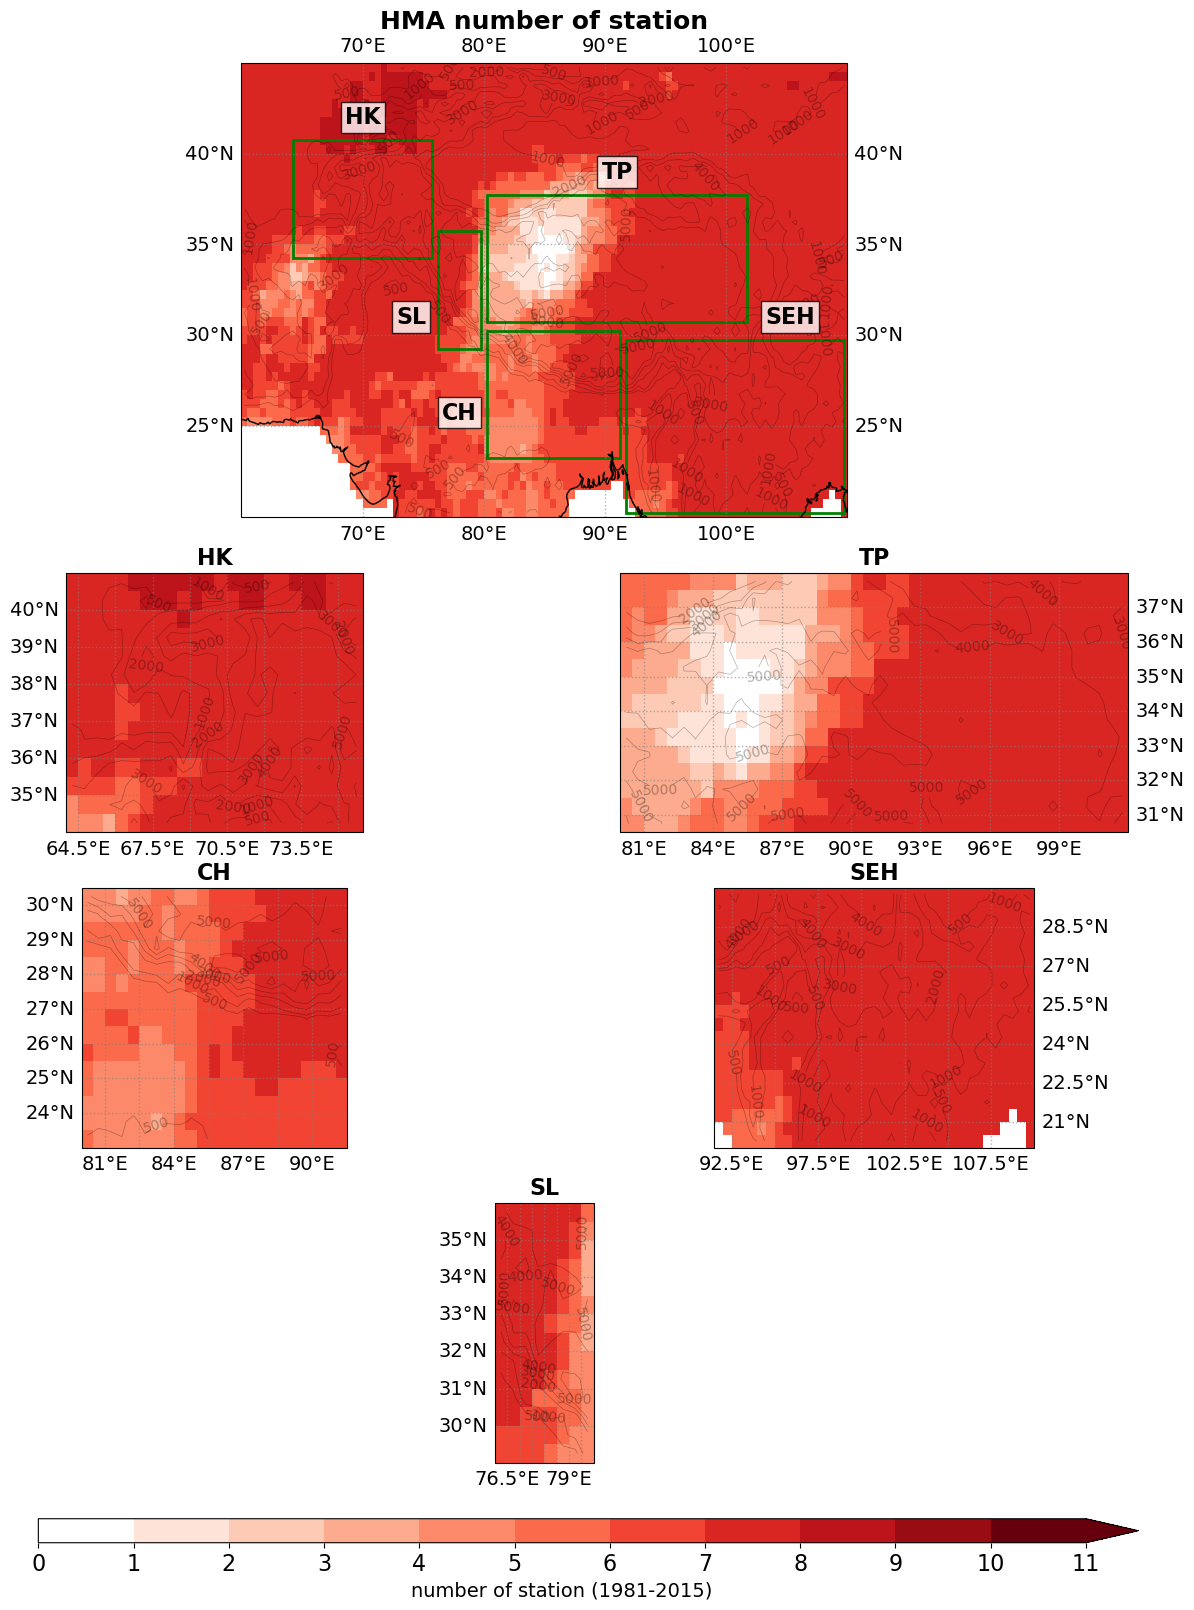

In [13]:
levels = np.arange(0,12,1)

cmap = plt.get_cmap('Reds', len(levels)-1)
colors = cmap(np.arange(cmap.N))
colors[0] = [1,1,1,1]   # blanc
cmap = mcolors.ListedColormap(colors)

norm = mcolors.BoundaryNorm(levels, plt.get_cmap(cmap).N)

# Compute rectangle coordinates automatically
CH_box = [LONS_CH.min().item(), LONS_CH.max().item(),
             LATS_CH.min().item(), LATS_CH.max().item()]

HK_box = [LONS_HK.min().item(), LONS_HK.max().item(),
             LATS_HK.min().item(), LATS_HK.max().item()]

TP_box = [LONS_TP.min().item(), LONS_TP.max().item(),
             LATS_TP.min().item(), LATS_TP.max().item()]

SEH_box = [LONS_SEH.min().item(), LONS_SEH.max().item(),
             LATS_SEH.min().item(), LATS_SEH.max().item()]

SL_box = [LONS_SL.min().item(), LONS_SL.max().item(),
             LATS_SL.min().item(), LATS_SL.max().item()]

# Create figure and gridspec layout
fig = plt.figure(figsize=(22, 40))
gs = fig.add_gridspec(4, 2, height_ratios=[1.75, 1, 1, 1])

# Row 1: full-width HMA plot
ax0 = fig.add_subplot(gs[0, :], projection=ccrs.PlateCarree())
CS0 = ax0.pcolormesh(LONS_hma, LATS_hma,dsSH_hma,
                   transform=ccrs.PlateCarree(),
                   cmap=cmap ,norm=norm ,shading="auto")
ax0.coastlines()
ax0.set_title('HMA number of station',fontsize=18,weight="bold")
gl = ax0.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="gray", alpha=0.6, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}
ax0.set_aspect(1.5)
SH0 = ax0.contour(LONS_elev_HMA, LATS_elev_HMA, elev_HMA,
                             levels=[500,1000,2000,3000,4000,5000,6000,7000],
                             colors="k", linewidths=0.5, alpha=0.3,
                             transform=ccrs.PlateCarree())
ax0.clabel(SH0, inline=True, fontsize=10, fmt="%d")

# Add red rectangles for subdomains
for box in [CH_box, HK_box, TP_box, SEH_box, SL_box]:
    rect = Rectangle((box[0], box[2]), box[1]-box[0], box[3]-box[2],
                     linewidth=2, edgecolor='green', facecolor='none', transform=ccrs.PlateCarree())
    ax0.add_patch(rect)

#Add text zone
latS, latN, lonW, lonE = coord_domain('HK')
ax0.text((lonW + lonE) / 2, latN + 1, "HK",horizontalalignment='center',verticalalignment='center',fontsize=16,fontweight='bold',
        color='black',transform=ccrs.PlateCarree(),zorder=7,bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))
latS, latN, lonW, lonE = coord_domain('TP')
ax0.text((lonW + lonE) / 2, latN + 1, "TP",horizontalalignment='center',verticalalignment='center',fontsize=16,fontweight='bold',
        color='black',transform=ccrs.PlateCarree(),zorder=7,bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))
latS, latN, lonW, lonE = coord_domain('CH')
ax0.text(lonW - 2,(latS + latN) / 2 - 1, "CH",horizontalalignment='center',verticalalignment='center',fontsize=16,fontweight='bold',
        color='black',transform=ccrs.PlateCarree(),zorder=7,bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))
latS, latN, lonW, lonE = coord_domain('SEH')
ax0.text((lonW + lonE) / 2 + 4.5, latN + 1, "SEH",horizontalalignment='center',verticalalignment='center',fontsize=16,fontweight='bold',
        color='black',transform=ccrs.PlateCarree(),zorder=7,bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))
latS, latN, lonW, lonE = coord_domain('SL')
ax0.text(lonW - 2,(latS + latN) / 2 - 1.5, "SL",horizontalalignment='center',verticalalignment='center',fontsize=16,fontweight='bold',
        color='black',transform=ccrs.PlateCarree(),zorder=7,bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))

# Row 2: HK & TP subdomain plots
ax1 = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree())
CS1 = ax1.pcolormesh(LONS_HK, LATS_HK,dsSH_HK,
                   transform=ccrs.PlateCarree(),
                   cmap=cmap ,norm=norm ,shading="auto")

ax1.set_title('HK',fontsize=16,weight="bold")
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="gray", alpha=0.6, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}
gl.top_labels = False
gl.right_labels = False
ax1.set_aspect(1.5)
SH1 = ax1.contour(LONS_elev_HK, LATS_elev_HK, elev_HK,
                             levels=[500,1000,2000,3000,4000,5000,6000,7000],
                             colors="k", linewidths=0.5, alpha=0.3,
                             transform=ccrs.PlateCarree())
ax1.clabel(SH1, inline=True, fontsize=10, fmt="%d")


ax2 = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree())
CS2 = ax2.pcolormesh(LONS_TP, LATS_TP,dsSH_TP,
                   transform=ccrs.PlateCarree(),
                   cmap=cmap ,norm=norm ,shading="auto")

ax2.set_title('TP',fontsize=16,weight="bold")
gl = ax2.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="gray", alpha=0.6, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}
gl.top_labels = False
gl.left_labels = False
ax2.set_aspect(1.5)
SH2 = ax2.contour(LONS_elev_TP, LATS_elev_TP, elev_TP,
                             levels=[500,1000,2000,3000,4000,5000,6000,7000],
                             colors="k", linewidths=0.5, alpha=0.3,
                             transform=ccrs.PlateCarree())
ax2.clabel(SH2, inline=True, fontsize=10, fmt="%d")

# Row 3: CH & SEH subdomain plots
ax3 = fig.add_subplot(gs[2, 0], projection=ccrs.PlateCarree())
CS3 = ax3.pcolormesh(LONS_CH, LATS_CH,dsSH_CH,
                   transform=ccrs.PlateCarree(),
                   cmap=cmap ,norm=norm ,shading="auto")

ax3.set_title('CH',fontsize=16,weight="bold")
gl = ax3.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="gray", alpha=0.6, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}
gl.top_labels = False
gl.right_labels = False
ax3.set_aspect(1.5)
SH3 = ax3.contour(LONS_elev_CH, LATS_elev_CH, elev_CH,
                             levels=[500,1000,2000,3000,4000,5000,6000,7000],
                             colors="k", linewidths=0.5, alpha=0.3,
                             transform=ccrs.PlateCarree())
ax3.clabel(SH3, inline=True, fontsize=10, fmt="%d")

ax4 = fig.add_subplot(gs[2, 1], projection=ccrs.PlateCarree())
CS4 = ax4.pcolormesh(LONS_SEH, LATS_SEH,dsSH_SEH,
                   transform=ccrs.PlateCarree(),
                   cmap=cmap ,norm=norm ,shading="auto")

ax4.set_title('SEH',fontsize=16,weight="bold")
gl = ax4.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="gray", alpha=0.6, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}
gl.top_labels = False
gl.left_labels = False
ax4.set_aspect(1.5)
SH4 = ax4.contour(LONS_elev_SEH, LATS_elev_SEH, elev_SEH,
                             levels=[500,1000,2000,3000,4000,5000,6000,7000],
                             colors="k", linewidths=0.5, alpha=0.3,
                             transform=ccrs.PlateCarree())
ax4.clabel(SH4, inline=True, fontsize=10, fmt="%d")

# Row 4: SL subdomain plots
ax5 = fig.add_subplot(gs[3, :], projection=ccrs.PlateCarree())
CS5 = ax5.pcolormesh(LONS_SL, LATS_SL,dsSH_SL,
                   transform=ccrs.PlateCarree(),
                   cmap=cmap ,norm=norm ,shading="auto")

ax5.set_title('SL',fontsize=16,weight="bold")
gl = ax5.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="gray", alpha=0.6, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}
gl.top_labels = False
gl.right_labels = False
ax5.set_aspect(1.5)
SH5 = ax5.contour(LONS_elev_SL, LATS_elev_SL, elev_SL,
                             levels=[500,1000,2000,3000,4000,5000,6000,7000],
                             colors="k", linewidths=0.5, alpha=0.3,
                             transform=ccrs.PlateCarree())
ax5.clabel(SH5, inline=True, fontsize=10, fmt="%d")

cbar_ax = fig.add_axes([0.27, 0.18, 0.5, 0.006])  # [left, bottom, width, height]
cbar = fig.colorbar(CS0, cax=cbar_ax, orientation="horizontal", ticks=levels, extend='max')
cbar.set_label(f'number of station ({iyear}-{fyear})', fontsize=14)
cbar.ax.tick_params(labelsize=16)

fig.subplots_adjust(left=0.2, right=0.8, top=0.55, bottom=0.2, wspace=0.00000001, hspace=0.18)

plt.show()

In [14]:
print(f"HK : {dsSH_HK.mean(dim=['longitude','latitude'], skipna=True):.3f} \n"
    f"TP : {dsSH_TP.mean(dim=['longitude','latitude'], skipna=True):.3f} \n"
    f"CH : {dsSH_CH.mean(dim=['longitude','latitude'], skipna=True):.3f} \n"
    f"SEH : {dsSH_SEH.mean(dim=['longitude','latitude'], skipna=True):.3f} \n"
    f"SL : {dsSH_SL.mean(dim=['longitude','latitude'], skipna=True):.3f} \n")

HK : 7.655 
TP : 5.825 
CH : 6.176 
SEH : 7.658 
SL : 6.461 



In [17]:
station_raw = gpcp_data['stn']

In [18]:
station = station_raw.sel(time=slice(str(1901),str(2020)))
station = field_dom(station, 'HMA')
station = station.mean(dim=['latitude','longitude'], skipna=True)

station1 = station_raw.sel(time=slice(str(1901),str(2020)))
station1 = field_dom(station1, 'HK')
station1 = station1.mean(dim=['latitude','longitude'], skipna=True)

station2 = station_raw.sel(time=slice(str(1901),str(2020)))
station2 = field_dom(station2, 'TP')
station2 = station2.mean(dim=['latitude','longitude'], skipna=True)

station3 = station_raw.sel(time=slice(str(1901),str(2020)))
station3 = field_dom(station3, 'CH')
station3 = station3.mean(dim=['latitude','longitude'], skipna=True)

station4 = station_raw.sel(time=slice(str(1901),str(2020)))
station4 = field_dom(station4, 'SEH')
station4 = station4.mean(dim=['latitude','longitude'], skipna=True)

station5 = station_raw.sel(time=slice(str(1901),str(2020)))
station5 = field_dom(station5, 'SL')
station5 = station5.mean(dim=['latitude','longitude'], skipna=True)

station_dict = {'HMA' : station,
                'HK': station1,
                'TP': station2,
                'CH': station3,
                'SEH': station4,
                'SL': station5}


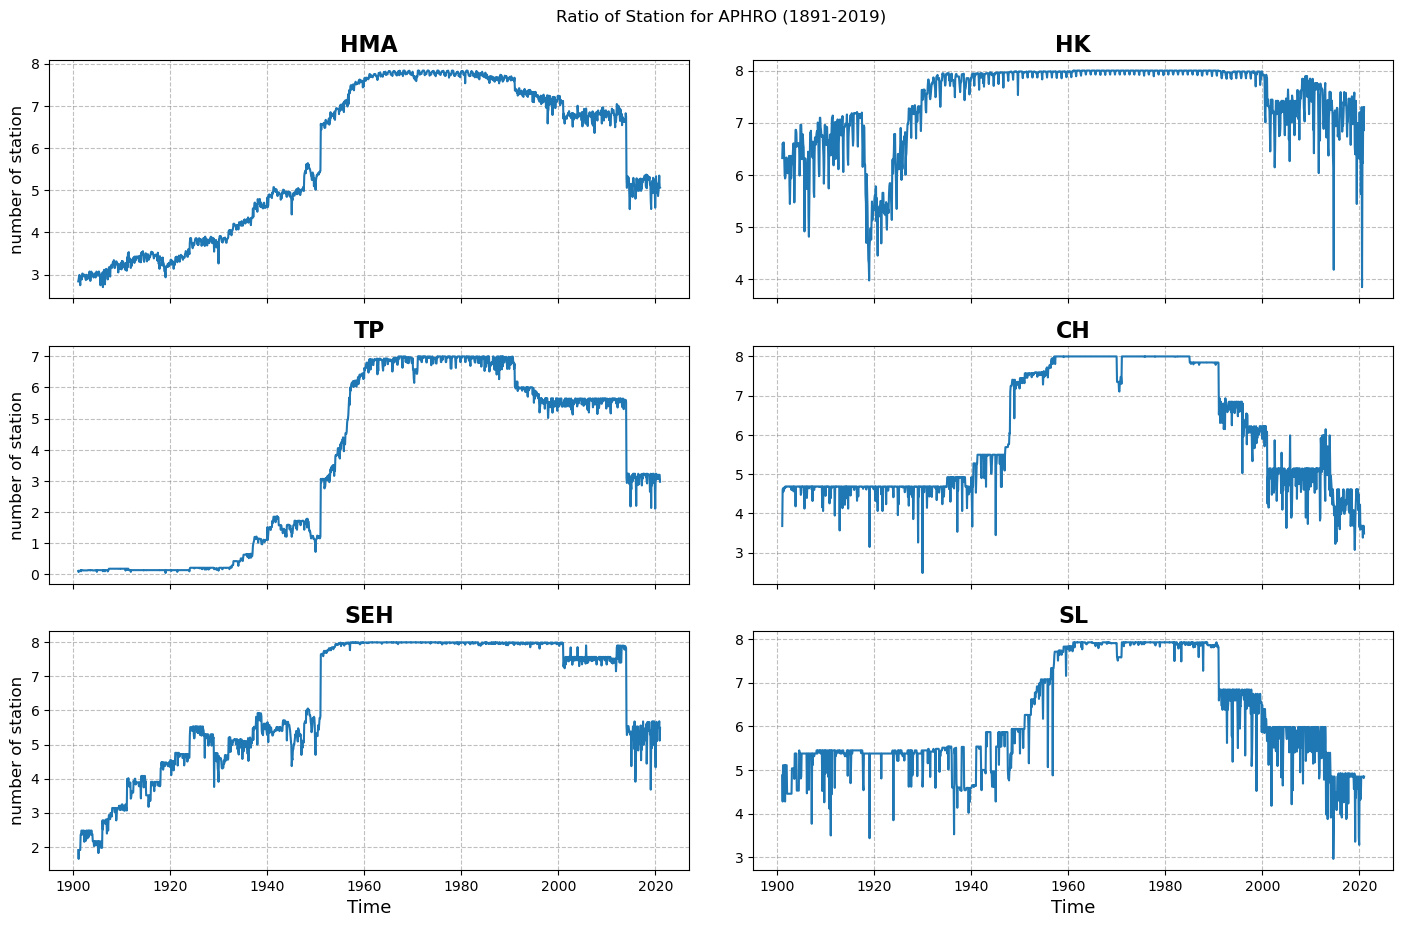

In [19]:
fig, axes = plt.subplots(3, 2, figsize=(16, 10))
axes = axes.flatten()

for i,ax in enumerate(axes):

    domain=list(station_dict.keys())[i]
    
    station = station_dict[domain]
    
    ax.plot(station.time.values, station.values)
    ax.grid(linestyle='--', color='gray', alpha=0.5)
    ax.set_title(f'{domain}', fontsize=16, weight='bold')

    if i in [0, 2, 4]:  # colonne gauche
        ax.set_ylabel('number of station', fontsize=12)
        ax.tick_params(labelleft=True)
    else:
        ax.tick_params(labelleft=True)  # pas de labels pour colonne droite

    if i in [4, 5]:  # ligne du bas
        ax.set_xlabel('Time', fontsize=13)
        ax.tick_params(labelbottom=True)
    else:
        ax.tick_params(labelbottom=False)  # pas de labels pour ligne du haut

fig.subplots_adjust(left=0.08, right=0.92, top=0.93, bottom=0.12, wspace=0.1, hspace=0.2)
fig.suptitle('Ratio of Station for APHRO (1891-2019)')
plt.show()
